1. Load Dataset & Normalize Features

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

df = pd.read_csv('C:/Users/Administrator/Documents/Dhruvil/Projects/Data Science/Data Science xl files/Iris.csv')

# Drop the 'Id' column and separate features (X) from target (y)
X = df.drop(['Id', 'Species'], axis=1)
y = df['Species']

# Encode the string target labels ('Iris-setosa', etc.) to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42
)

# Standardize features using z-score normalization (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

2 & 3. KNN Experimentation with values of K

In [11]:
k_values = range(1, 21)
accuracies = []

# Loop through different K values to find the best performing model
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred_k))

best_k = k_values[np.argmax(accuracies)]
print(f"Optimal K found: {best_k} (Accuracy: {max(accuracies):.4f})")

Optimal K found: 3 (Accuracy: 1.0000)


4. Final Evaluation & Confusion Matrix

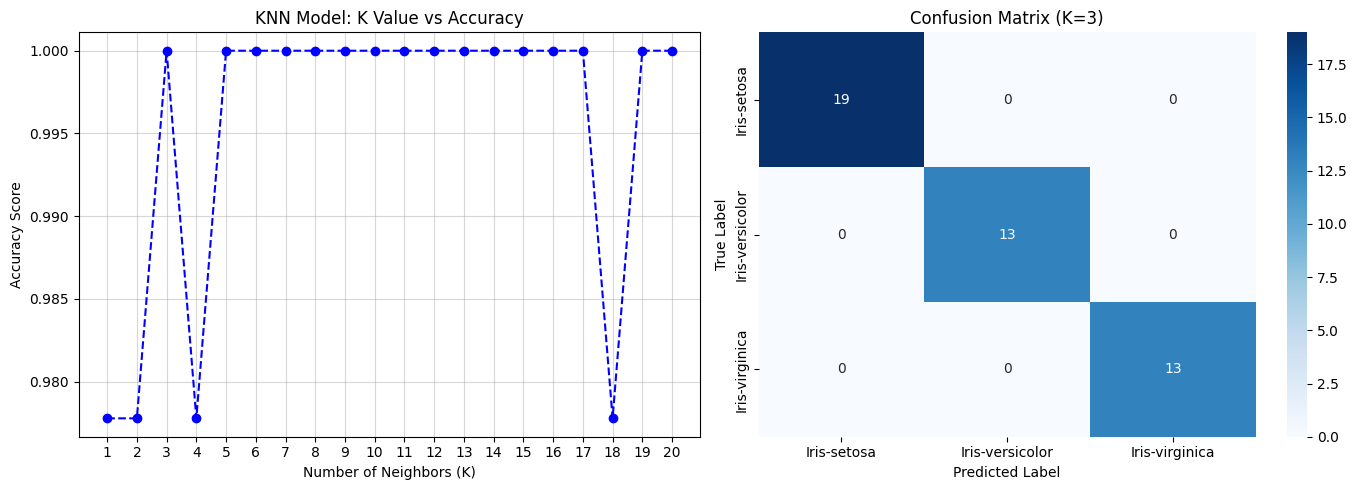

In [12]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
y_pred = final_knn.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

# Plotting K-Value Experiment and Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: K-Value Accuracy Curve
axes[0].plot(k_values, accuracies, marker='o', linestyle='dashed', color='blue')
axes[0].set_title('KNN Model: K Value vs Accuracy')
axes[0].set_xlabel('Number of Neighbors (K)')
axes[0].set_ylabel('Accuracy Score')
axes[0].set_xticks(k_values)
axes[0].grid(True, alpha=0.5)

# Plot 2: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title(f'Confusion Matrix (K={best_k})')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
plt.tight_layout()
plt.show()

5. Visualize Decision Boundaries

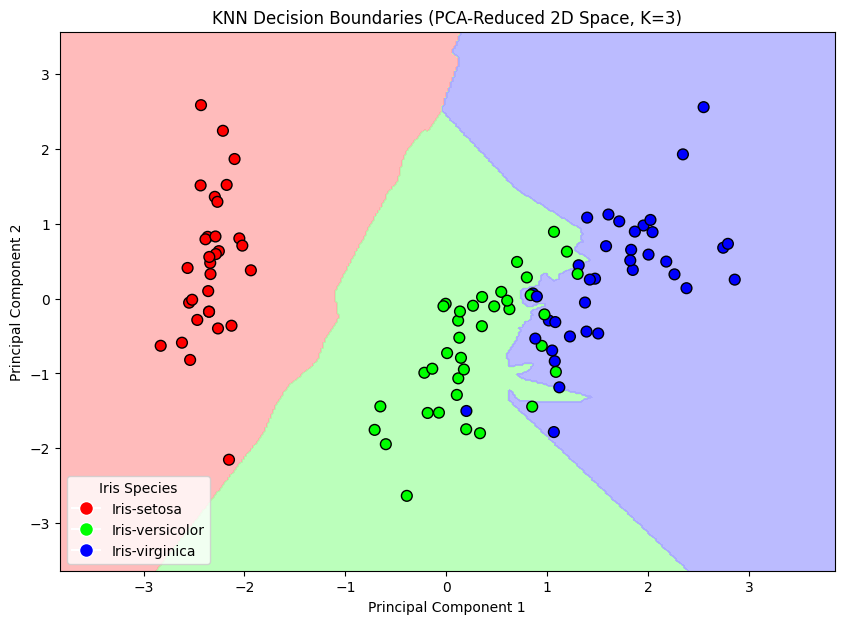

In [13]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train a specialized KNN on the 2D PCA data to match the visual space
knn_pca = KNeighborsClassifier(n_neighbors=best_k)
knn_pca.fit(X_train_pca, y_train)

# Create a uniform mesh grid covering the coordinate space
h = .02
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict classifications across the entire mesh grid
Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting the decision boundary contours
plt.figure(figsize=(10, 7))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

# Overlay the actual training data points
scatter = plt.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1], 
    c=y_train, cmap=cmap_bold, edgecolor='k', s=60
)

# Generate custom legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap_bold.colors[i], 
           markersize=10, label=le.classes_[i]) for i in range(3)]
plt.legend(handles=handles, title="Iris Species")

plt.title(f"KNN Decision Boundaries (PCA-Reduced 2D Space, K={best_k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()